---------------------
Imports and setup
---------------------

**This is for all of the tasks in both steps (1 and 2)*

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd
import re, nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

[nltk_data] Downloading package stopwords to /Users/eyad/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = pd.read_csv("Data/IMDB Dataset.csv")

---------------------
STEP 1
---------------------

**Task 1.1**

1 - We output the first 5 rows of data

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


2- We print the shape of the dataset (how many rows and columns it has)

In [6]:
print(f" (rows, columns) \n {df.shape}")

 (rows, columns) 
 (50000, 2)


3- We check for any missing values in each column

In [7]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

4- We check the class balance (How many positve reviews and negative reviews and see if they are balanced)

In [8]:
print(df["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


5- If the class balanced had a big difference we would've balanced it using F1 score

**Task 1.2**

1- Here we make an 80,20 split (this code is from the objectives paper I just combined the two code block together)

In [9]:
stop_words = set(stopwords.words('english'))

def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # remove punctuation
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['review'].apply(clean)

X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Convert text to numbers with TF-IDF ---

tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(X_train) # learn vocab on train only
X_test = tfidf.transform(X_test) # apply to test (no fitting!)

**Task 1.3**

*Here is the function we are going to use (Google gemini 3.1 pro helped me with it)*

In [10]:
results = {}

def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):

    print(f"--- Training {model_name} ---")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label = "positive")
    rec = recall_score(y_test, y_pred, pos_label = "positive")
    f1 = f1_score(y_test, y_pred, pos_label = "positive")

    results[model_name] = {
        "Accuracy" : acc,
        "Precision" : prec,
        "Recall" : rec,
        'F1 Score' : f1
    }

    print(f"Accuracy : {acc:.4f} | Precision : {prec:.4f} | Recall : {rec:.4f} | F1 Score {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    disp =  ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = model.classes_)
    disp.plot(cmap = "Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

1 & 2 & 3- Here we train our 3 models (Logistic Regression, Random Forest and KNN ), report accuracy, percision, recall and F1 score and plot a confusion matrix for each model all using the function that we made

--- Training Logistic Regression ---
Accuracy : 0.8892 | Precision : 0.8828 | Recall : 0.8976 | F1 Score 0.8901


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


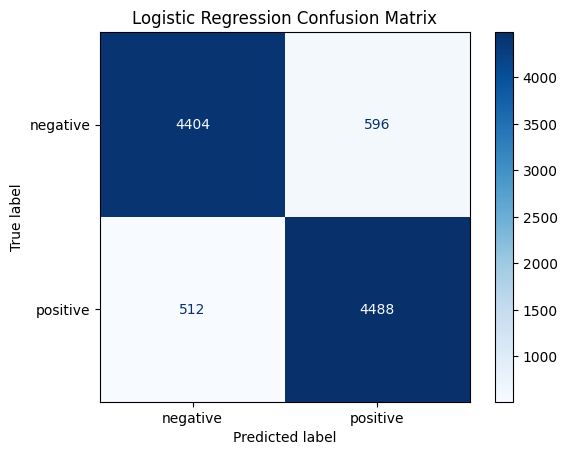

--- Training Random Forest ---
Accuracy : 0.8227 | Precision : 0.7898 | Recall : 0.8794 | F1 Score 0.8322


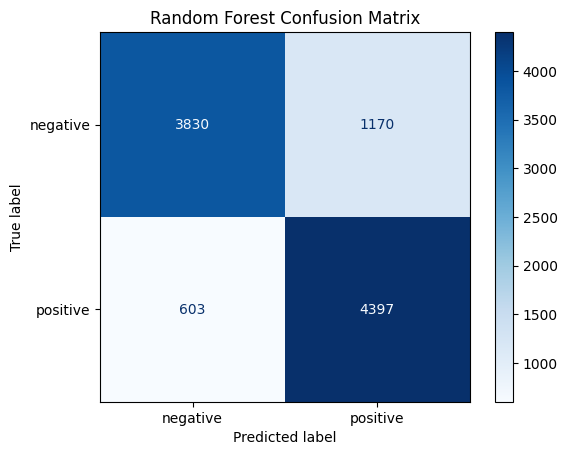

--- Training KNN ---
Accuracy : 0.7421 | Precision : 0.7175 | Recall : 0.7986 | F1 Score 0.7559


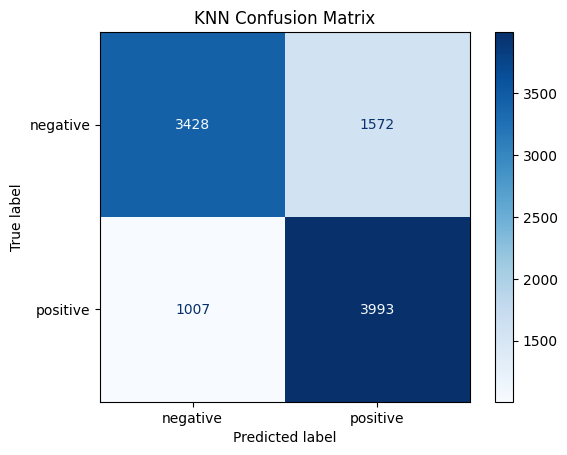

In [11]:
logReg = LogisticRegression(max_iter = 1000, random_state = 42)
RF = RandomForestClassifier(n_estimators = 100, max_depth = 10, random_state = 42)
KNN = KNeighborsClassifier(n_neighbors = 5)

evaluate_model("Logistic Regression", logReg, X_train, y_train, X_test, y_test)
evaluate_model("Random Forest", RF, X_train, y_train, X_test, y_test)
evaluate_model("KNN", KNN, X_train, y_train, X_test, y_test)

4- Last but not least we put all of the results into one summary table and choose the best model

In [12]:
summary_table = pd.DataFrame(results)
print("\nModel performance summary table : ")
summary_table


Model performance summary table : 


,Logistic Regression,Random Forest,KNN
Accuracy,0.889200,0.822700,0.742100
Precision,0.882769,0.789833,0.717520
Recall,0.897600,0.879400,0.798600
F1 Score,0.890123,0.832213,0.755892


**(I have used Google gemini 3.1 pro to search where I can find the information I need from the sildes)*

---------------------
STEP 2
---------------------

**Task 2.1**

In [13]:
y_train_enc = pd.Series(y_train).map({"positive" : 1, "negative" : 0}).values
y_test_enc = pd.Series(y_test).map({"positive" : 1, "negative" : 0}).values

1 & 2- Build a neural network using Keras Dense layers with ReLU and Sigmoid/Softmax and Add at least one Dropout layer to reduce overfitting

In [14]:
model = Sequential()

model.add(Dense(128, activation = "relu", input_shape = (5000, )))
model.add(Dropout(0.3))
model.add(Dense(64, activation = "relu"))
model.add(Dense(1, activation = "sigmoid"))

model.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

3- Train for at least 10 epochs

In [15]:
history = model.fit(
    X_train.toarray(),
    y_train_enc,
    epochs = 15,
    batch_size = 32,
    validation_data = (X_test.toarray(), y_test_enc)
)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8630 - loss: 0.3193 - val_accuracy: 0.8835 - val_loss: 0.2748
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9095 - loss: 0.2233 - val_accuracy: 0.8862 - val_loss: 0.2718
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9394 - loss: 0.1644 - val_accuracy: 0.8836 - val_loss: 0.3088
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9714 - loss: 0.0898 - val_accuracy: 0.8777 - val_loss: 0.3802
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9867 - loss: 0.0419 - val_accuracy: 0.8776 - val_loss: 0.5060
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9930 - loss: 0.0221 - val_accuracy: 0.8755 - val_loss: 0.6075
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9947 - loss: 0.0150 - val_accuracy: 0.8725 - val_loss: 0.6882
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9953 - loss: 0.0127 - 

4- Plot the training vs. validation loss and accuracy curves

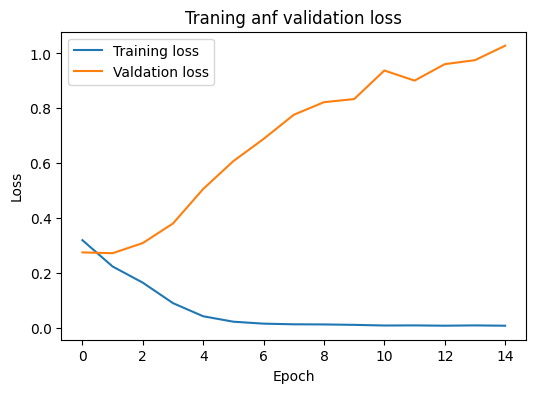

In [16]:
plt.figure(figsize = (6, 4))
plt.plot(history.history["loss"], label = "Training loss")
plt.plot(history.history["val_loss"], label = "Valdation loss")
plt.title("Traning anf validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Task 2.2**

1- Evaluate the neural network on the test set using the same metrics as Step 1

In [17]:
y_pred_prob = model.predict(X_test.toarray())
y_pred_enc = (y_pred_prob > 0.5).astype(int)

acc_enc = accuracy_score(y_test_enc, y_pred_enc)
prec_enc = precision_score(y_test_enc, y_pred_enc)
rec_enc = recall_score(y_test_enc, y_pred_enc)
f1_enc = f1_score(y_test_enc, y_pred_enc)

print("Nueral Network Metrics : ")
print(f"Accuracy : {acc_enc:.4f}")
print(f"Precision : {prec_enc:.4f}")
print(f"Recall : {rec_enc:.4f}")
print(f"F1 Score : {f1_enc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step
Nueral Network Metrics : 
Accuracy : 0.8707
Precision : 0.8908
Recall : 0.8450
F1 Score : 0.8673


2- Add the neural network results to your summary table from Step 1

In [21]:
results["Neural Network"] = {
    "Accuracy": acc_enc,
    "Precision": prec_enc,
    "Recall": rec_enc,
    "F1 Score": f1_enc
}

summary_table = pd.DataFrame(results)
print("Model performance summary table : ")
summary_table

Model performance summary table : 


,Logistic Regression,Random Forest,KNN,Neural Network
Accuracy,0.889200,0.822700,0.742100,0.870700
Precision,0.882769,0.789833,0.717520,0.890786
Recall,0.897600,0.879400,0.798600,0.845000
F1 Score,0.890123,0.832213,0.755892,0.867289


To see if the neural network is better or not we have to see how the different models place to eachother in each metric.
Accuracy : 1 - Logistic Regression, 2 - Neural Network, 3 - Random Forest, 4 - KNN
Precision : 1 - Neural Network, 2 - Logistic Regression, 3 - Random Forest, 4 - KNN
Recall : 1 - Logistic Regression, 2 - Neural Network, 3 - Random Forest, 4 - KNN
F1 Score : 1 - Logistic Regression 2 - Neural Network, 3 - Random Forest, 4 - KNN

If we look at how the different models place we see a pattern that Logistic Regression is better than Neural Network in every metric but the Neural network is better than everything else

so basically : **Logistic Regression > Neural Network (15 epochs) > Random Forest > K's Nearest Neighbors**